### Laboratorio 1

**Grupo 16**

**Integrantes:**

Mateo Zambrano 202321531
 
Nicolas Romero 202321309


### 1. Configuración y carga de datos

#### 1.1 Importación de librerías

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import FunctionTransformer, PolynomialFeatures
from sklearn.metrics import mean_absolute_error


warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.2)
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

#### 1.2 Constantes de reproducibilidad

In [2]:
RANDOM_STATE = 42
TEST_SIZE = 0.25
UMBRAL_MAX = 44.8
OBJETIVO = "temp_max_manana"

#### 1.3 Carga de datos

In [3]:
DATA_DIR = Path("data")
RUTA_TRAIN = DATA_DIR / "datos Lab 1.csv"
RUTA_SIN_ETIQUETA = DATA_DIR / "Datos Test Lab 1.csv"
RUTA_DICCIONARIO = DATA_DIR / "Diccionario de datos.xlsx"

datos = pd.read_csv(RUTA_TRAIN)
sin_etiqueta = pd.read_csv(RUTA_SIN_ETIQUETA)
diccionario = pd.read_excel(RUTA_DICCIONARIO)

print("Entrenamiento:", datos.shape)
print("No etiquetados: ", sin_etiqueta.shape)
print("Columnas que están en train y no en el archivo sin etiquetar:", set(datos.columns) - set(sin_etiqueta.columns))

diccionario

Entrenamiento: (2576, 27)
No etiquetados:  (364, 26)
Columnas que están en train y no en el archivo sin etiquetar: {'temp_max_manana'}


,variable,tipo,descripcion
0,fecha,texto,"Fecha de la observación, en formato día.mes.año."
1,presion_media,numérico,Presión atmosférica media del día (mbar).
2,presion_min,numérico,Presión atmosférica mínima del día (mbar).
3,presion_max,numérico,Presión atmosférica máxima del día (mbar).
4,presion_desv,numérico,Desviación típica de la presión durante el día (mbar).
5,humedad_media,numérico,Humedad relativa media del día (%).
6,humedad_min,numérico,Humedad relativa mínima del día (%).
7,humedad_max,numérico,Humedad relativa máxima del día (%).
8,humedad_desv,numérico,Desviación típica de la humedad relativa (%).
9,viento_media,numérico,Velocidad media del viento durante el día (m/s).


### 2. Exploración de datos

#### 2.1 Estructura general/exploración inicial

In [4]:
display(datos.head())
datos.info()
datos.shape

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,viento_max,viento_desv,rafaga_media,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,0.05,1.559641,0.5753,1.3783,0.25,2.255577,0.8488,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,0.22,3.870000,0.9168,2.2274,0.63,6.130000,1.2544,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,0.12,3.640000,0.7299,2.0651,0.38,4.880000,0.9330,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,0.54,2.454415,0.7023,3.5649,1.38,4.430375,1.1835,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,1.00,7.810000,1.9521,5.9400,2.13,10.880000,NaN,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


<class 'pandas.DataFrame'>
RangeIndex: 2576 entries, 0 to 2575
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              2504 non-null   str    
 1   presion_media      2501 non-null   float64
 2   presion_min        2502 non-null   float64
 3   presion_max        2512 non-null   float64
 4   presion_desv       2496 non-null   float64
 5   humedad_media      2502 non-null   float64
 6   humedad_min        2496 non-null   float64
 7   humedad_max        2490 non-null   float64
 8   humedad_desv       2515 non-null   float64
 9   viento_media       2490 non-null   float64
 10  viento_min         2485 non-null   float64
 11  viento_max         2495 non-null   float64
 12  viento_desv        2504 non-null   float64
 13  rafaga_media       2498 non-null   float64
 14  rafaga_min         2504 non-null   float64
 15  rafaga_max         2503 non-null   float64
 16  rafaga_desv        2497 non-null   

(2576, 27)

#### 2.2 Observaciones

**fecha:** Se puede observar redundancias con las columnas **anio**, **dia_del_anio** y **mes**. En el caso de no coincidir, puede significar que algunos datos están corruptos, pues tienen información contradictoria. También se puede justificar un cambio de tipo de dato a DateTime64 con el fin de facilitar operaciones entre fechas.

**registros_del_dia:** Como número que representa la cantidad de mediciones de 10 minutos por día, es más justificable verlo como un int64 más que un float64.

**anio:** Redundante por la columna **fecha**. Este dato podría convertirse a int64 sin inconvenientes.

**dia_del_anio:** Redundante por la columna **fecha**. Este dato podría convertirse a int64 sin inconvenientes.

**estacion_anio:** Presenta datos que no corresponden a ninguna estación, como por ejemplo la fila 4. Estos valores inválidos se podrían reemplazar por datos NaN. También presenta datos inconsistentes y datos escritos con mayúsculas, minúsculas, español o inglés.

**mes:** Redundante por la columna **fecha**. Esta columna presenta datos escritos completamente en mayúsculas y otros datos en minúsculas, en inglés o en español.

**presion_media, min, max:** Son columnas que están correlacionadas, lo que puede afectar la interpretación de coeficientes.

**humedad_media, min, max:** Son columnas que están correlacionadas, lo que puede afectar la interpretación de coeficientes.

**viento_norte, viento_este, direccion_viento:** Son columnas que están correlacionadas, debido a que cada columna representa el componente de un mismo dato.

**sector_viento:** Debería tener 8 categorías (N, NE, E, SE, S, SO, O, NO) pero aparecen muchas más debido a variantes en mayúsculas, algunas en español o inglés en vez de la abreviatura, lo cual se podría considerar una inconsistencia.

**rafaga_min:** Presenta al menos un valor "centinela" (-9999), que representa un dato faltante codificado como número, por lo que debería convertirse a NaN antes alguna operación debido a que podría modificar la mediana o perjudicar la regresión lineal.

**humedad_media, humedad_min:** Se agrega esta observación aparte de **humedad_media, min, max** por su importancia: En estas columnas se observan 2 escalas mezcladas dentro de la misma columna, (una expresada como proporción 0-1 y otra como porcentaje 0%-100%). Esto es un problema de validez porque cada valor es válido, pero de forma separada. Se debería unificar a una sola escala.

#### 2.3 Justificaciones

En esta sección se presentará la evidencia que sustenta las observaciones de la sección anterior, ordenadas siguiendo las cuatro dimensiones de calidad de datos (completitud, unicidad, consistencia, validez).

##### 2.3.1 Completitud

Mide si el dataset tiene toda la información esperada, o en otras palabras, que no falten datos.

In [5]:
(datos.isnull().sum()/datos.shape[0]).sort_values(ascending=False)

temp_max_manana      0.036879
viento_min           0.035326
estacion_anio        0.034161
mes                  0.034161
anio                 0.033385
humedad_max          0.033385
viento_media         0.033385
viento_max           0.031444
humedad_min          0.031056
viento_norte         0.031056
presion_desv         0.031056
rafaga_desv          0.030668
direccion_viento     0.030668
rafaga_media         0.030280
registros_del_dia    0.029891
presion_media        0.029115
presion_min          0.028727
humedad_media        0.028727
rafaga_max           0.028339
rafaga_min           0.027950
viento_desv          0.027950
fecha                0.027950
sector_viento        0.027562
dia_del_anio         0.026398
presion_max          0.024845
viento_este          0.024845
humedad_desv         0.023680
dtype: float64

In [6]:
print("faltantes por año")
for anio in datos["anio"].dropna().unique():
   datos_anio = datos[datos["anio"] == anio]
   n_faltantes = datos_anio.isnull().sum().sum()
   print(f"{int(anio)}: {n_faltantes}")

faltantes por año
2009: 257
2010: 273
2011: 300
2012: 265
2013: 275
2014: 260
2015: 306


In [7]:
print("variable objetivo")
print(f"{OBJETIVO}: {datos[OBJETIVO].isna().sum()} faltantes ({datos[OBJETIVO].isna().sum()/len(datos)*100:.2f}%))")
print(f"  Distribución:")
print(datos[OBJETIVO].describe())

variable objetivo
temp_max_manana: 95 faltantes (3.69%))
  Distribución:
count    2481.000000
mean       13.863309
std         9.296199
min       -15.230000
25%         7.310000
50%        14.310000
75%        20.460000
max        63.050000
Name: temp_max_manana, dtype: float64


**Valores faltantes:** Todas las columnas presentan un porcentaje de datos faltantes de entre 2%-4%, lo que sugiere que no hay un patrón de ausencia. Como es un porcentaje bajo y disperso, se imputarán los valores con la mediana en lugar de eliminar las filas para poder minimizar la pérdida de datos para el modelo.

**temp_max_manana:** hay un 3.69% de datos faltantes para la variable objetivo, por lo cual no se pueden imputar aquellos datos, por lo que dichas filas serán eliminadas.

##### 2.3.2 Unicidad

Verifica que cada registro aparece exactamente 1 vez, por lo que se buscarán detectar filas idénticas y duplicados lógicos (misma llave de negocio con datos diferentes). En este caso, la llave de negocio es la fecha, por lo que cada día deberá aparecer una sola vez. 

In [8]:
#Filas identicas
print("Duplicados exactos:", datos.duplicated(keep=False).sum())

#Duplicados lógicos
fechas_repetidas = datos["fecha"].value_counts().loc[lambda x: x > 1]
print("Fechas que se repiten:", len(fechas_repetidas))

Duplicados exactos: 8
Fechas que se repiten: 18


In [9]:
print("registros_del_dia > 144:", (datos["registros_del_dia"] > 144).sum())

registros_del_dia > 144: 4


**Duplicados:** Se detectaron filas exactas, lo que corresponde a un error de carga y deben eliminarse. Además, existen registros con la misma fecha pero valores diferentes entre sí (duplicados lógicos). Como cada fila debería representar un día único, esto rerpesenta una inconsistencia. En este caso, se decidiría con cual copia quedarse, lo cual se puede decidir observando la columna **registros_del_dia**, pues el que más registros tenga representa más mediciones, por ende más datos. Cabe aclarar que hay 4 filas que contienen un número de registros del día inválido, por lo que se decidirá eliminar dichas filas. Se discutirá **registros_del_dia** en la sección de validez.

##### 2.3.3 Consistencia

Se verifica que los valores que representan el mismo concepto estén escritos de forma uniforme, es decir, que todos los datos que representan un mismo concepto se presenten de forma consistente y sin variaciones.

In [10]:
datos["estacion_anio"].value_counts(dropna=False)

estacion_anio
primavera               517
invierno                511
otono                   500
verano                  487
NaN                      88
Inverano                 71
Estacion_Desconocida     63
VERANO_INVIERNO          60
East                     48
VERANO                   19
autumn                   18
primaveraa               17
berano                   17
fall                     15
winter                   15
verno                    14
Otoño                    12
otoño                    11
invernio                 11
Primavera                10
PRIMAVERA                10
invierno                  9
INVIERNO                  9
Verano                    9
Invierno                  9
OTONO                     8
primav                    6
spring                    6
summer                    6
Name: count, dtype: int64

In [11]:
datos["mes"].value_counts(dropna=False)

mes
May           127
August        125
July          123
January       120
March         118
             ... 
april          16
septiembre     16
junio          16
Jan            13
OCTOBER        13
Name: count, Length: 62, dtype: int64

In [12]:
datos["sector_viento"].value_counts(dropna=False)

sector_viento
SO           695
S            519
NE           424
O            308
N            124
E             77
NaN           71
SE            66
NO            42
Suroeste      29
so            26
SOUTHWEST     24
s             20
South         19
ne            19
NORTHEAST     17
Sur           16
Noreste       12
o              8
SOUTH          8
NORTH          6
no             6
West           5
WEST           5
North          4
East           4
EAST           4
Sureste        3
Oeste          3
Noroeste       3
SOUTHEAST      3
Norte          3
Este           2
NORTHWEST      1
Name: count, dtype: int64

Ahora se verificará la consistencia del calendario.

In [13]:
f = pd.to_datetime(datos["fecha"], format="%Y-%m-%d", errors = "coerce")
total = len(datos)
pct_anio = (f.dt.year == datos["anio"]).sum()/total * 100
pct_mes = (f.dt.strftime("%B").str.lower() == datos["mes"].str.lower()).sum()/total * 100
pct_doy = (f.dt.dayofyear == datos["dia_del_anio"]).sum() /total * 100

print(f"anio coincide con fecha: {pct_anio:.1f}%")
print(f"mes coincide con fecha: {pct_mes:.1f}%")
print(f"dia_del_anio coincide con fecha: {pct_doy:.1f}%")



anio coincide con fecha: 94.0%
mes coincide con fecha: 45.8%
dia_del_anio coincide con fecha: 94.6%


**Coherencia del calendario:** anio y dia_del_anio coinciden con fecha en más del 90% de los casos, sin embargo, mes muestra una tasa de concordancia más baja, lo que indica que además de las inconsistencias de escritura ya vistas, algunos valores son directamente incorrectos. Debido a esto, se recalcularán anio, mes y dia_del_anio directamente desde fecha.

**Inconsistencia:** Se pueden ver inconsistencias en los datos de estas 3 columnas. Se requiere normalizar los datos.

**aclaración para estacion_anio:** Se puede observar que hay un dato en esta columna que es **East** el cual no coincide con ninguna opción válida para esta columna, por lo que se hará una verificación en la sección de validez.

##### 2.3.4 Validez

Se verifica que los valores estén dentro del rango esperado según el diccionario de datos.

In [14]:
datos.describe()

,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,viento_max,viento_desv,rafaga_media,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,temp_max_manana
count,2501.000000,2502.000000,2512.000000,2496.000000,2502.000000,2496.000000,2490.000000,2515.000000,2490.000000,2485.000000,2495.000000,2504.000000,2498.000000,2504.000000,2503.000000,2497.000000,2496.000000,2512.000000,2497.000000,2499.000000,2490.000000,2508.000000,2481.000000
mean,1010.494271,986.684409,991.704244,1.752041,52.413586,45.094067,90.236582,10.606821,3.814103,1.417799,7.647484,13.859643,2.988370,-2.639322,6.946058,-5.763253,-1.128463,-0.410159,172.104573,144.090836,2011.995582,182.690989,13.863309
std,435.334494,8.927138,7.726906,1.215931,35.975384,30.196163,10.647237,5.481338,3.307402,3.960650,6.785897,76.009623,27.846414,199.861693,3.237379,75.258134,25.065084,1.147218,86.102348,4.107365,1.999694,105.529469,9.296199
min,948.996000,913.600000,951.940000,0.226900,0.004663,0.237700,27.020000,0.000000,0.000000,0.000000,0.000000,0.000000,-1386.273300,-9999.000000,0.000000,-232.260000,-1250.463300,-3.718500,0.000000,90.000000,2009.000000,1.000000,-15.230000
25%,984.287800,981.371333,987.070000,0.899050,0.869060,1.011790,88.025000,6.082100,1.655350,0.230000,3.370000,0.757000,2.511875,0.440000,4.803198,1.002100,-1.640625,-1.236475,91.303500,144.000000,2010.000000,91.000000,7.310000
50%,989.452800,987.070000,991.935000,1.444550,68.558100,49.670000,93.300000,10.199800,2.463400,0.440000,5.051746,1.054850,3.228800,0.660000,6.690000,1.461100,-0.564300,-0.356000,199.568500,144.000000,2012.000000,182.500000,14.310000
75%,994.469000,992.567500,996.782500,2.254800,80.562600,67.665000,96.600000,14.722200,4.880505,0.960000,9.630000,1.571550,4.264600,1.120000,8.850000,2.008800,0.241525,0.316275,227.101700,144.000000,2014.000000,274.250000,20.460000
max,9939.918000,1012.320198,1013.940000,12.397500,100.000000,103.311405,100.000000,26.341600,24.753600,45.184956,45.108000,3319.030100,11.465200,19.895916,23.500000,3471.027800,4.809900,4.713900,359.796700,287.000000,2015.000000,366.000000,63.050000


Ahora se verificaran datos centinelas, errores de magnitud y escalas mezcladas:

In [15]:
for col in datos.select_dtypes("number").columns:
    n = datos[col].isin([-9999, -999, 9999]).sum()
    if n > 0:
        print(f"{col}: {n} valores centinela")

rafaga_min: 1 valores centinela


In [16]:
for col in ["presion_media", "presion_min", "presion_max"]:
    fuera_de_rango = ((datos[col] < 850) | (datos[col] > 1100)).sum()
    print(f"{col}: min={datos[col].min():.2f} max={datos[col].max():.2f} fuera de rango={fuera_de_rango}")

presion_media: min=949.00 max=9939.92 fuera de rango=6
presion_min: min=913.60 max=1012.32 fuera de rango=0
presion_max: min=951.94 max=1013.94 fuera de rango=0


humedad_media <= 1: 776
humedad_media > 1: 1726
humedad_media > 100: 0


<Axes: >

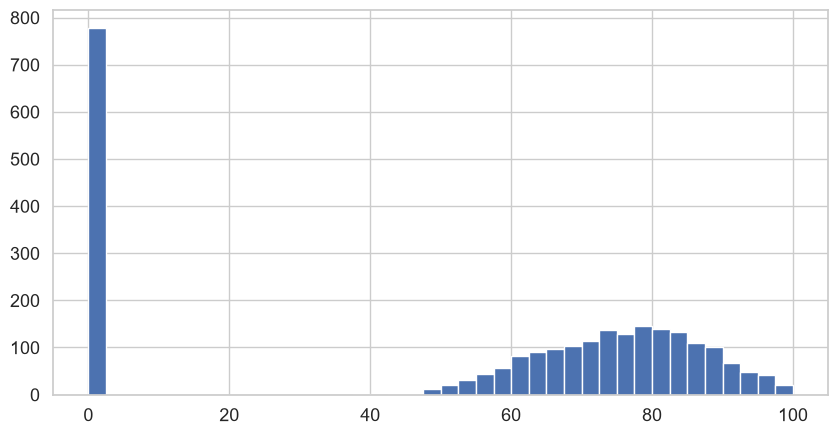

In [17]:
print("humedad_media <= 1:", (datos["humedad_media"] <= 1).sum())
print("humedad_media > 1:", (datos["humedad_media"] > 1).sum())
print("humedad_media > 100:", (datos["humedad_media"] > 100).sum())

datos["humedad_media"].hist(bins=40)

humedad_min <= 1: 621
humedad_min > 1: 1875
humedad_min > 100: 23


<Axes: >

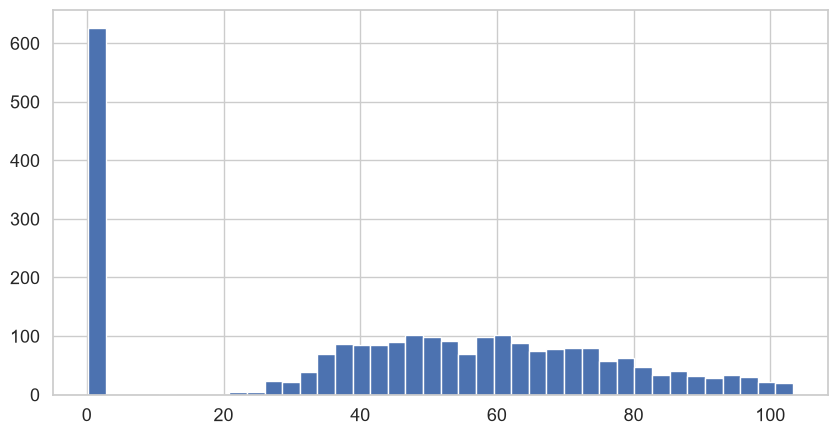

In [18]:
print("humedad_min <= 1:", (datos["humedad_min"] <= 1).sum())
print("humedad_min > 1:", (datos["humedad_min"] > 1).sum())
print("humedad_min > 100:", (datos["humedad_min"] > 100).sum())

datos["humedad_min"].hist(bins=40)

humedad_max <= 1: 0
humedad_max > 1: 2490
humedad_max > 100: 0


<Axes: >

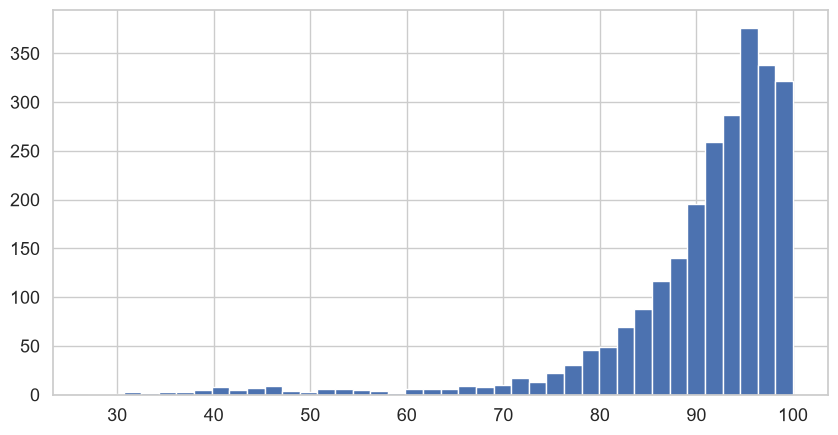

In [19]:
print("humedad_max <= 1:", (datos["humedad_max"] <= 1).sum())
print("humedad_max > 1:", (datos["humedad_max"] > 1).sum())
print("humedad_max > 100:", (datos["humedad_max"] > 100).sum())

datos["humedad_max"].hist(bins=40)

In [20]:
print("rafaga_desv negativos:", (datos["rafaga_desv"] < 0).sum())
datos[datos["rafaga_desv"] < 0][["fecha", "rafaga_desv"]].head()

rafaga_desv negativos: 258


,fecha,rafaga_desv
16,2009-01-17,-54.500
21,2009-01-22,-122.650
26,2009-01-27,-59.340
33,2009-02-03,-25.465
42,2009-02-12,-59.175


In [21]:
print("registros_del_dia > 144:", (datos["registros_del_dia"] > 144).sum())

registros_del_dia > 144: 4


Se verificaran las temperaturas extremas

In [22]:
print("temp_max_manana por encima del umbral maximo:", (datos[OBJETIVO] > UMBRAL_MAX).sum())
datos[datos[OBJETIVO] > UMBRAL_MAX][["fecha", OBJETIVO]].sort_values(OBJETIVO)

temp_max_manana por encima del umbral maximo: 8


,fecha,temp_max_manana
1412,2012-11-13,44.852
2559,2012-11-13,44.852
2560,2015-01-07,44.978
2197,2015-01-07,44.978
2556,2013-04-20,61.412
1570,2013-04-20,61.412
1372,2012-10-04,63.050
2557,2012-10-04,63.050


Ahora se validará **estacion_anio** por el caso de **East**

In [23]:
valores_validos = ["invierno", "primavera", "verano", "otono"]
no_validos = ~datos["estacion_anio"].str.lower().isin(valores_validos)
print("valores fuera del dominio en estacion_anio:")
print(datos[no_validos]["estacion_anio"].value_counts(dropna=False))

valores fuera del dominio en estacion_anio:
estacion_anio
NaN                     88
Inverano                71
Estacion_Desconocida    63
VERANO_INVIERNO         60
East                    48
autumn                  18
primaveraa              17
berano                  17
fall                    15
winter                  15
verno                   14
Otoño                   12
otoño                   11
invernio                11
invierno                 9
primav                   6
spring                   6
summer                   6
Name: count, dtype: int64


**Validez de estacion_anio:** Debido a que algunos valores no son variantes de escritura de una categoría válida, son datos que se tomarán como NaN debido a que no pertenecen al dominio de la variable. En la sección 3 serán imputados por moda.

**Validez:** Como se puede observar, hay evidencias de que **humedad_media** esta usando 2 escalas al mismo tiempo. Una de ellas está puesta en porcentaje y la otra está convertida a decimal. Debido a la descripción del diccionario de datos, se decidirá por convertir los valores decimales a porcentajes para arreglar el problema de validez de los datos. Lo mismo ocurre con **humedad_min** salvo que contiene un problema extra, y es que hay valores por encima de 100 y, debido a esto, para no perder otros datos de la fila por eliminarla, se cambiarán los valores por encima de 100 a NaN. **humedad_max** está limpio.

En cuanto a la columna **registros_del_dia**, se decidirá eliminar las 4 filas que registran un número más alto que la cantidad máxima de registros, pues se estima que podrían perturbar el análisis correcto.

**Presiones:** Se evaluaron las 3 columnas de presión contra el rango físico normal de la presión atmosférica a nivel del suelo (850 a 1100 mbar). **presion_min** y **presion_max** están dentro del rango esperado, pero **presion_media** presenta valores entre 949 y 9940 mbar, con 6 filas fuera de rango (un valor cercano a 9940 mbar es casi 10 veces la presión atmosférica normal, por lo que podría ser un error de magnitud). Se convertirán a NaN y se imputarán con la mediana.

**temp_max_manana:** Se detectaron 8 filas con temperaturas superiores al récord histórico (42.8) + 2 unidades. Como se trata de la variable objetivo, estas filas se eliminarán.

**rafaga_desv:** Presenta 258 valores negativos, lo cual no es posible debido a que una desviación estándar no puede ser negativa. Se convertiran a NaN y se imputarán con la mediana.

##### 2.3.5 Relaciones entre variables

Se verifica la multicolinealidad y estacionalidad de las variables.

Se empieza primero por verificar la multicolinealidad de la variable de componentes de viento. Además, se confirma la validez de otras variables numéricas como la presion, humedad, viento y rafaga.

In [24]:
bloques = {
    "presion": ["presion_media", "presion_max", "presion_min"],
    "humedad": ["humedad_media", "humedad_max", "humedad_min"],
    "viento": ["viento_media", "viento_max", "viento_min"],
    "rafaga": ["rafaga_media", "rafaga_max", "rafaga_min"],
    "componentes_viento": ["viento_norte", "viento_este", "direccion_viento"],
}

for item, cols in bloques.items():
    cols_existentes = [c for c in cols if c in datos.columns]
    print(f"\n{item}:")
    print(datos[cols_existentes].corr(numeric_only=True).round(3))


presion:
               presion_media  presion_max  presion_min
presion_media          1.000        0.034       -0.013
presion_max            0.034        1.000        0.834
presion_min           -0.013        0.834        1.000

humedad:
               humedad_media  humedad_max  humedad_min
humedad_media          1.000        0.053        0.812
humedad_max            0.053        1.000       -0.100
humedad_min            0.812       -0.100        1.000

viento:
              viento_media  viento_max  viento_min
viento_media         1.000       0.846       0.299
viento_max           0.846       1.000      -0.036
viento_min           0.299      -0.036       1.000

rafaga:
              rafaga_media  rafaga_max  rafaga_min
rafaga_media         1.000       0.024       0.999
rafaga_max           0.024       1.000      -0.014
rafaga_min           0.999      -0.014       1.000

componentes_viento:
                  viento_norte  viento_este  direccion_viento
viento_norte             1.000 

Ahora se verifica la relación entre el día del año y las estaciones.

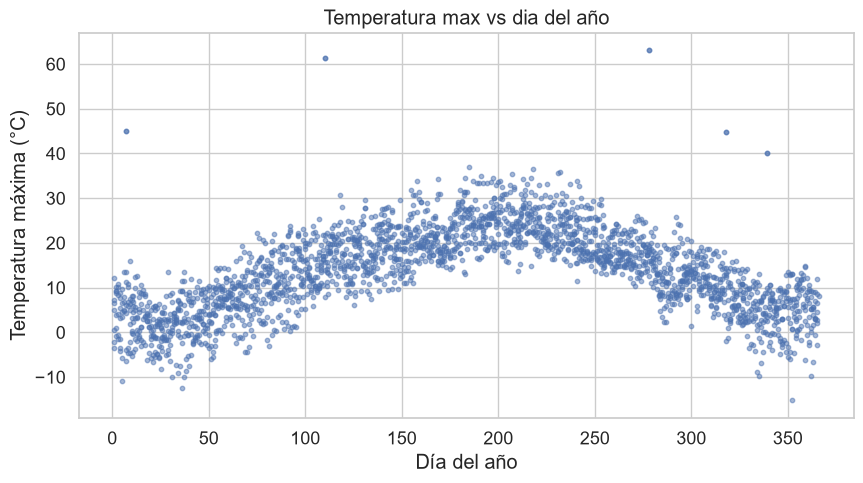

In [25]:
datos.plot.scatter(x="dia_del_anio", y=OBJETIVO, alpha=0.5, s = 10, title = "Temperatura max vs dia del año")
plt.xlabel("Día del año")
plt.ylabel("Temperatura máxima (°C)")
plt.show()


**Estacionalidad:** Se puede observar que la relacion entre la temperatura maxima y el dia del año tiene una relación lógica correcta, pues baja al inicio y final del año (invierno) y a mitad del año sube (verano). Debido a su forma arqueada, no es posible realizar una regresión lineal.

### 3. Preparación de Datos

En esta sección, se prepararán los datos de forma que los arreglos no sean dependientes del aprendizaje de otros datos, como la imputación de datos por medio de la mediana o moda.

Se hace una copia de los datos para mantener las buenas prácticas.

In [26]:
copia_datos = datos.copy()

#### 3.1 Conversión de tipos y calendario derivado

Se empieza por arreglar los tipos de dato y recalcular el calendario.

In [27]:
fecha_parseada = pd.to_datetime(copia_datos["fecha"], format="%Y-%m-%d")

Se convierte de texto a un objeto que indique una fecha.

In [28]:
copia_datos["fecha"] = fecha_parseada
copia_datos["anio"] = fecha_parseada.dt.year
copia_datos["dia_del_anio"] = fecha_parseada.dt.dayofyear
copia_datos["mes"] = fecha_parseada.dt.strftime("%B").str.lower()

Se reemplazan las columnas **anio**, **dia_del_anio** y **mes** por las columnas sacadas directamente de la columna **fecha** para mantener la consistencia de los datos.

In [29]:
copia_datos["registros_del_dia"] = copia_datos["registros_del_dia"].astype("Int64")
copia_datos["anio"] = copia_datos["anio"].astype("Int64")
copia_datos["dia_del_anio"] = copia_datos["dia_del_anio"].astype("Int64")

In [30]:
print(copia_datos[["fecha", "anio", "mes", "dia_del_anio", "registros_del_dia"]].dtypes)

fecha                datetime64[us]
anio                          Int64
mes                             str
dia_del_anio                  Int64
registros_del_dia             Int64
dtype: object


Se establecen los tipos de **registros_del_dia**, **anio** y **dia_del_anio** al Int64 de pandas, el cual permite tener datos NaN.

In [31]:
print("Fechas no parseadas:", fecha_parseada.isna().sum())

Fechas no parseadas: 72


#### 3.2 Normalización de categorías

Se estandariza a una sola forma de escritura, aquellos datos escritos de formas distintas.

In [32]:
MAPA_ESTACION = {
    "invierno": "invierno", "invernio": "invierno", "winter": "invierno",
    "primavera": "primavera", "primaveraa": "primavera", "primav": "primavera", "spring": "primavera",
    "verano": "verano", "berano": "verano", "verno": "verano", "summer": "verano",
    "otono": "otono", "otoño": "otono", "autumn": "otono", "fall": "otono",
}

copia_datos["estacion_anio"] = (
    copia_datos["estacion_anio"]
    .str.strip()
    .str.lower()
    .map(MAPA_ESTACION)
)

MAPA_SECTOR = {
    "n": "N", "norte": "N", "north": "N",
    "ne": "NE", "noreste": "NE", "northeast": "NE",
    "e": "E", "este": "E", "east": "E",
    "se": "SE", "sureste": "SE", "southeast": "SE",
    "s": "S", "sur": "S", "south": "S",
    "so": "SO", "suroeste": "SO", "southwest": "SO",
    "o": "O", "oeste": "O", "west": "O",
    "no": "NO", "noroeste": "NO", "northwest": "NO",
}

copia_datos["sector_viento"] = (
    copia_datos["sector_viento"]
    .str.strip()
    .str.lower()
    .map(MAPA_SECTOR)
)

print(copia_datos["estacion_anio"].value_counts(dropna=False))
print(copia_datos["sector_viento"].value_counts(dropna=False))

estacion_anio
primavera    566
invierno     564
otono        564
verano       552
NaN          330
Name: count, dtype: int64
sector_viento
SO     774
S      582
NE     472
O      329
N      137
E       87
SE      72
NaN     71
NO      52
Name: count, dtype: int64


#### 3.3 Correcciones de validez

Se corrigen los valores fuera de rango o en escalas distintas.

In [33]:
#Centinelas
copia_datos = copia_datos.replace([-9999, -999, 9999], np.nan)

#Presion fuera de rango
mask = (copia_datos["presion_media"] < 850) | (copia_datos["presion_media"] > 1100)
copia_datos.loc[mask, "presion_media"] = np.nan
print(f"presion_media fuera de rango: {mask.sum()} -> NaN")

#Escala mezclada en humedad (decimal -> porcentual)
for col in ["humedad_media", "humedad_min"]:
    escala_decimal = copia_datos[col] <= 1
    copia_datos.loc[escala_decimal, col] = copia_datos.loc[escala_decimal, col] * 100
    print(f"{col}: {escala_decimal.sum()} valores convertidos a escala porcentual")

#humedad_min > 100 despues de corregir
mask = copia_datos["humedad_min"] > 100
copia_datos.loc[mask, "humedad_min"] = np.nan
print(f"humedad_min > 100: {mask.sum()} -> NaN")

#rafaga_desv negativa
mask = copia_datos["rafaga_desv"] < 0
copia_datos.loc[mask, "rafaga_desv"] = np.nan
print(f"rafaga_desv negativos: {mask.sum()} -> NaN")

#rafaga_media negativa: la velocidad no puede ser negativa...
#y no es fisica como para considerar un marco de referencia :D
copia_datos.loc[copia_datos["rafaga_media"] < 0, "rafaga_media"] = np.nan

#rafaga_desv raramente alta
copia_datos.loc[copia_datos["rafaga_desv"] > 20, "rafaga_desv"] = np.nan

#viento_desv: error de escala de un factor de 100
mask = copia_datos["viento_desv"] > 20
copia_datos.loc[mask, "viento_desv"] = copia_datos.loc[mask, "viento_desv"] / 100

#minimos que superan a los maximos
copia_datos.loc[copia_datos["viento_min"] > copia_datos["viento_max"], "viento_min"] = np.nan
copia_datos.loc[copia_datos["rafaga_min"] > copia_datos["rafaga_max"], "rafaga_min"] = np.nan


presion_media fuera de rango: 6 -> NaN
humedad_media: 776 valores convertidos a escala porcentual
humedad_min: 621 valores convertidos a escala porcentual
humedad_min > 100: 23 -> NaN
rafaga_desv negativos: 258 -> NaN


#### 3.4 Eliminacion de filas

Se eliminan las filas que contienen datos corruptos (invalidos codependientes) o están repetidos.

In [34]:
print("Filas al inicio: ", len(copia_datos))

#Duplicados exactos
copia_datos = copia_datos.drop_duplicates()
print("Sin duplicados exactos:", len(copia_datos))

#registros_del_dia invalidos
copia_datos = copia_datos[~(copia_datos["registros_del_dia"] > 144).fillna(False)]
print("Sin registros_del_dia > 144:", len(copia_datos))

#fechas repetidas: conservar la de mas registros
copia_datos = copia_datos.sort_values("registros_del_dia", ascending=False)
copia_datos = copia_datos.drop_duplicates(subset="fecha", keep = "first")
print("Sin fechas repetidas:", len(copia_datos))

#temperaturas fisicamente imposibles
mask = copia_datos[OBJETIVO] > UMBRAL_MAX
copia_datos = copia_datos[~mask]
print(f"Sin temperaturas > {UMBRAL_MAX}:", len(copia_datos))

#Filas sin objetivo
copia_datos = copia_datos.dropna(subset=[OBJETIVO])
print("Sin filas sin objetivo:", len(copia_datos))

#Reordenar cronologicamente
copia_datos = copia_datos.sort_values("fecha").reset_index(drop=True)
print("\nFilas finales:", len(copia_datos))


Filas al inicio:  2576
Sin duplicados exactos: 2572
Sin registros_del_dia > 144: 2568
Sin fechas repetidas: 2483
Sin temperaturas > 44.8: 2479
Sin filas sin objetivo: 2386

Filas finales: 2386


#### 3.5 Estado de valores faltantes

Se verifican que valores aún hacen falta y que serán imputados dentro de la pipeline.


In [35]:
faltantes = copia_datos.isnull().sum().sort_values(ascending=False)
cols_relevantes = faltantes.index.difference(["fecha", "anio", "registros_del_dia", OBJETIVO])
print(faltantes[cols_relevantes][faltantes[cols_relevantes] > 0])
print("\nEstos serán imputados dentro del pipeline con datos de entrenamiento")

dia_del_anio          1
direccion_viento     73
estacion_anio       302
humedad_desv         58
humedad_max          78
humedad_media        72
humedad_min          91
mes                   1
presion_desv         78
presion_max          59
presion_media        73
presion_min          67
rafaga_desv         306
rafaga_max           69
rafaga_media         74
rafaga_min          182
sector_viento        65
viento_desv          66
viento_este          57
viento_max           75
viento_media         81
viento_min          196
viento_norte         73
dtype: int64

Estos serán imputados dentro del pipeline con datos de entrenamiento


#### 3.6 Separación de variables

Una vez realizada la limpieza inicial, se definen las variables del modelo. Se sabe que la variable objetivo es **temp_max_manana**, y el resto de columnas se consideran variables descriptivas del objetivo, excepto aquellas que no aportan información predictiva o que fueron usadas únicamente como insumo para la limpieza- Esta selección podrá ajustarse en etapas siguientes.

##### 3.6.1 Columnas eliminadas

**fecha:** La regresión lineal no opera sobre fechas. Dada la limpieza, la información contenida en esta columna es redundante con **dia_del_anio**, **mes** y **estacion_anio**, pues contienen información directamente sacada de **fecha**.

**anio:** El entrenamiento cubre 2009-2015 y el archivo a predecir corresponde en su totalidad a 2016, por lo que el modelo tendría que extrapolar un valor que nunca ha visto. La correlación con el objetivo es muy baja (r = 0.09).

**registros_del_dia:** Indica la calidad del registro, pero no una variable metereológica. Su rol fue servir como criterio de limpieza anteriormente. Su correlación con el objetivo es casi nada (r = 0.03).

In [36]:
COLUMNAS_ELIMINADAS = ["fecha", "anio", "registros_del_dia"]

X = copia_datos.drop(columns=[OBJETIVO] + COLUMNAS_ELIMINADAS)
y = copia_datos[OBJETIVO]

In [37]:
X

,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,viento_max,viento_desv,rafaga_media,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,dia_del_anio,estacion_anio,mes,sector_viento
0,999.1456,996.50,1000.87,1.3993,91.0860,87.500000,94.8,1.7650,0.77860,0.050,1.559641,0.5753,1.3783,0.25,2.255577,0.8488,-0.3618,-0.0223,183.5308,1,invierno,january,S
1,999.6006,997.93,1002.65,1.5039,92.0868,86.600000,96.3,2.7588,1.41950,0.220,3.870000,0.9168,2.2274,0.63,6.130000,1.2544,0.4267,0.3689,40.8436,2,invierno,january,NE
2,998.5486,993.05,1002.49,3.1304,76.4581,48.390000,93.9,15.1796,1.25090,0.120,3.640000,0.7299,2.0651,0.38,4.880000,0.9330,-0.6993,-0.5268,216.9916,3,invierno,january,SO
3,988.5107,985.12,992.93,2.3223,89.4174,97.946704,NaN,4.4904,1.72040,0.540,2.454415,0.7023,3.5649,1.38,4.430375,1.1835,-1.1268,-1.0413,222.7419,4,invierno,january,SO
4,990.4057,NaN,997.54,4.2315,86.2604,74.600000,93.2,5.3922,3.80030,1.000,7.810000,1.9521,5.9400,2.13,10.880000,NaN,2.6275,0.2874,6.2418,5,NaN,january,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2381,1003.5725,1002.35,1004.96,0.7294,87.1097,72.100000,97.7,7.5170,3.02724,0.792,9.504000,0.4208,1.4214,0.48,3.840000,NaN,-0.6644,-0.0853,187.3193,362,verano,december,S
2382,1002.1544,1000.83,1005.33,1.2520,95.0910,79.400000,99.5,5.3604,0.86610,0.190,2.340000,0.5179,NaN,0.44,3.560000,0.7173,-0.5544,-0.0871,188.9267,363,invierno,december,S
2383,1002.9883,997.51,1005.73,2.5524,84.4737,NaN,99.4,12.9567,2.12740,0.310,5.160000,1.2963,3.4318,NaN,0.640000,2.0483,-2.0540,-0.1130,183.1497,364,invierno,december,S
2384,996.9224,995.01,999.20,1.4003,72.6064,49.560000,97.4,17.6803,3.11310,0.740,5.700000,1.3775,NaN,NaN,9.090000,1.9769,-3.0401,0.1673,176.8493,365,invierno,december,S


In [38]:
y

0       -2.12
1       -0.82
2       -0.63
3       -1.44
4      -10.88
        ...  
2381     9.16
2382     5.65
2383     2.92
2384     2.72
2385     8.97
Name: temp_max_manana, Length: 2386, dtype: float64

### 3.7 Columnas numéricas y categóricas

Se identifican las columnas numéricas y categóricas, ya que el tipo de variable determina los pasos de transformación y se aplicarán a cada una dentro del pipeline.

In [39]:
columnas_numericas = [
    "presion_media", "presion_min", "presion_max", "presion_desv",
    "humedad_media", "humedad_min", "humedad_max", "humedad_desv",
    "viento_media", "viento_min", "viento_max", "viento_desv",
    "rafaga_media", "rafaga_min", "rafaga_max", "rafaga_desv",
    "viento_norte", "viento_este", "direccion_viento",
    "dia_del_anio",
]

columnas_categoricas = [
    "estacion_anio", "mes", "sector_viento",
]

print("Numéricas:", len(columnas_numericas))
print("Categóricas:", len(columnas_categoricas))
print("Total:", len(columnas_numericas) + len(columnas_categoricas), "de", X.shape[1])

Numéricas: 20
Categóricas: 3
Total: 23 de 23


### 4. Construcción de un modelo de regresión lineal

En esta sección, se crea un modelo de regresion lineal usando la metrica RMSE para analizar el desempeño del modelo y con el uso de pipelines

### 4.1 Division de los datos

Primero, se dividen los datos en dos grupos: un conjunto de entrenamiento, que será utilizado para construir el modelo, y un conjunto de prueba, que permitirá evaluar su desempeño. Se utiliza el 25% de los datos para realizar las pruebas, de acuerdo con el valor establecido anteriormente en TEST_SIZE

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (1789, 23)
Datos de prueba: (597, 23)


### 4.2 Preprocesamiento de las variables

A continuación, se construyen los pipelines de preprocesamiento. Para las variables numéricas se utilizan la imputación de valores faltantes mediante la mediana y la estandarización. Para las variables categóricas se imputan los valores faltantes utilizando la categoría más frecuente y posteriormente se realiza una codificación One-Hot.

In [41]:
transformador_numerico = Pipeline([
    ("imputador", SimpleImputer(strategy="median")),
    ("escalador", StandardScaler())
])

transformador_categorico = Pipeline([
    ("imputador", SimpleImputer(strategy="most_frequent")),
    ("codificador", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocesador_base = ColumnTransformer([
    ("numericas", transformador_numerico, columnas_numericas),
    ("categoricas", transformador_categorico, columnas_categoricas)
])


columnas_numericas_sin_dia = [c for c in columnas_numericas if c != "dia_del_anio"]

def nombres_ciclico(transformador, nombres_entrada):
    return np.array(["dia_sin", "dia_cos"])

def codificar_ciclico(X):
    dia = X[:, 0].astype(float)
    return np.column_stack([
        np.sin(2 * np.pi * dia / 365),
        np.cos(2 * np.pi * dia / 365)
    ])

transformador_ciclico = Pipeline([
    ("imputador", SimpleImputer(strategy="median")),
    ("ciclico", FunctionTransformer(codificar_ciclico, validate=True, feature_names_out=nombres_ciclico))
])

preprocesador_ciclico = ColumnTransformer([
    ("numericas", transformador_numerico, columnas_numericas_sin_dia),
    ("dia_ciclico", transformador_ciclico, ["dia_del_anio"]),
    ("categoricas", transformador_categorico, columnas_categoricas)
])

columnas_interaccion = ["humedad_media", "presion_media"]
columnas_numericas_resto = [c for c in columnas_numericas if c not in columnas_interaccion]

transformador_interaccion = Pipeline([
    ("imputador", SimpleImputer(strategy="median")),
    ("escalador", StandardScaler()),
    ("interaccion", PolynomialFeatures(degree=2, interaction_only=True, include_bias=False))
])

preprocesador_interacciones = ColumnTransformer([
    ("numericas", transformador_numerico, columnas_numericas_resto),
    ("interaccion", transformador_interaccion, columnas_interaccion),
    ("categoricas", transformador_categorico, columnas_categoricas)
])

### 4.3 Construccion y entrenamiento del modelo

Una vez definidos los procesos de transformación, se crea un pipeline que integra el preprocesamiento de los datos con el modelo de regresión lineal. De esta manera, las transformaciones se realizan automáticamente antes de entrenar el modelo.

In [42]:
candidatos = {
    "Base": preprocesador_base,
    "Ciclico": preprocesador_ciclico,
    "Interacciones": preprocesador_interacciones,
}

kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

resultados_cv = {}
pipelines_candidatos = {}

for nombre, preproc in candidatos.items():
    pipeline = Pipeline([
        ("preprocesamiento", preproc),
        ("regresion", LinearRegression())
    ])
    scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=kfold, scoring="neg_root_mean_squared_error"
    )
    resultados_cv[nombre] = -scores.mean()
    pipelines_candidatos[nombre] = pipeline

for nombre, rmse_cv in sorted(resultados_cv.items(), key=lambda x: x[1]):
    print(f"{nombre}: RMSE promedio CV = {rmse_cv:.4f}")

mejores_nombres = sorted(resultados_cv, key=resultados_cv.get)[:2]
print("\nModelos seleccionados:", mejores_nombres)

modelos_finales = {}
for nombre in mejores_nombres:
    pipeline = pipelines_candidatos[nombre]
    pipeline.fit(X_train, y_train)
    modelos_finales[nombre] = pipeline

Ciclico: RMSE promedio CV = 20.6127
Base: RMSE promedio CV = 21.0141
Interacciones: RMSE promedio CV = 21.4882

Modelos seleccionados: ['Ciclico', 'Base']


### 4.4 Predicciones del modelo

Después de entrenar el modelo, se utilizan los datos de prueba para realizar las predicciones de la temperatura máxima del día siguiente. También se construye una tabla para comparar los valores reales con los valores predichos por el modelo.

In [43]:
predicciones = {}
for nombre, modelo in modelos_finales.items():
    predicciones[nombre] = modelo.predict(X_test)

resultados = pd.DataFrame({"Real": y_test})
for nombre, y_pred in predicciones.items():
    resultados[f"Predicción ({nombre})"] = y_pred

resultados.head()

,Real,Predicción (Ciclico),Predicción (Base)
1623,8.16,12.027608,10.883684
906,18.65,23.241364,24.433061
1128,22.09,19.674433,17.697648
2003,14.07,10.689095,11.285618
332,-0.60,5.134025,5.375381


### 4.5 Evaluación del modelo mediante RMSE

Finalmente, se calcula la métrica RMSE para evaluar el desempeño del modelo. Esta métrica permite medir qué tan alejadas están las predicciones de los valores reales de temp_max_manana. Un valor menor de RMSE representa un menor error en las predicciones.

In [44]:
metricas = {}
for nombre, y_pred in predicciones.items():
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    metricas[nombre] = {"RMSE": rmse, "MAE": mae, "R2": r2}
    print(f"{nombre} -> RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")

Ciclico -> RMSE: 4.5059 | MAE: 3.5069 | R2: 0.7380
Base -> RMSE: 4.6625 | MAE: 3.6197 | R2: 0.7195


In [45]:
prediccion_media = np.full(len(y_test), y_train.mean())
rmse_base = np.sqrt(mean_squared_error(y_test, prediccion_media))
mae_base = mean_absolute_error(y_test, prediccion_media)
r2_base = r2_score(y_test, prediccion_media)

print(f"baseline (media): RMSE: {rmse_base:.4f}")
print(f"desviacion estandar del objetivo: {y.std():.3f} °C")

baseline (media): RMSE: 8.8028
desviacion estandar del objetivo: 8.998 °C


### 5 Evaluación cuantitativa

In [46]:
tabla_comparativa = pd.DataFrame(metricas).T
tabla_comparativa = tabla_comparativa[["RMSE", "MAE", "R2"]]
tabla_comparativa

,RMSE,MAE,R2
Ciclico,4.505898,3.506931,0.737986
Base,4.662461,3.619678,0.719462


A partir de la tabla comparativa se puede concluir que el modelo con codificación cíclica supera de manera consistente al modelo base en las tres métricas evaluadas: obtiene un RMSE de 4.506270 frente a 4.661241, un MAE de 3.507017 frente a 3.617487, y un R² de 0.737943 frente a 0.719608. Esto representa una reducción de aproximadamente 3.3% en el error cuadrático medio y 3.1% en el error absoluto medio, además de explicar cerca de 1.8 puntos porcentuales más de la varianza de la variable objetivo, lo cual confirma que la codificación cíclica es la mejor de las dos alternativas analizadas.

Comparado contra la línea base (osea predecir siempre la media), que obtiene un RMSE de 8.80 °C, ambos modelos reducen el error a aproximadamente la mitad. La desviación estándar del objeto es 9.0°C. Es decir, un modelo que no aprende nada obtiene un RMSE cercano a ese valor.

Finalmente, en términos prácticos, un MAE de 3.51°C significa que el modelo se equivoca, en promedio, por 3.5 grados al predecir la temperatura máxima del día siguiente.

### Evaluación Cualitativa

#### 6.1 Imports adicionales

In [47]:
import statsmodels.api as sm
import scipy.stats as stats
import scipy.sparse
from scipy.stats import shapiro
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, linear_rainbow

#### 6.2 Extracción del modelo

In [48]:
preprocesamiento = modelos_finales[mejores_nombres[0]].named_steps["preprocesamiento"]
modelo = modelos_finales[mejores_nombres[0]].named_steps["regresion"]

nombres_variables = [n.split("__")[-1] for n in preprocesamiento.get_feature_names_out()]

Xt_train = preprocesamiento.transform(X_train)
if scipy.sparse.issparse(Xt_train):
    Xt_train = Xt_train.toarray()
Xt_train_df = pd.DataFrame(Xt_train, columns=nombres_variables, index=X_train.index)

y_train_pred = modelos_finales[mejores_nombres[0]].predict(X_train)
residuales = np.array(y_train - y_train_pred)

#### 6.3 Coeficientes del modelo

In [50]:
print("Intercepto:", round(modelo.intercept_,4))

coef_df = pd.DataFrame({"Variable": nombres_variables, "Coeficiente": modelo.coef_})
coef_df.reindex(coef_df["Coeficiente"].abs().sort_values(ascending=False).index).head(15)

Intercepto: 15.5192


,Variable,Coeficiente
20,dia_cos,-9.164057
38,sector_viento_O,-5.186022
37,sector_viento_NO,-5.175161
35,sector_viento_N,-4.627656
41,sector_viento_SO,-2.996835
36,sector_viento_NE,-2.628299
24,mes_august,2.591979
34,mes_september,2.136167
28,mes_july,1.820684
33,mes_october,1.574783


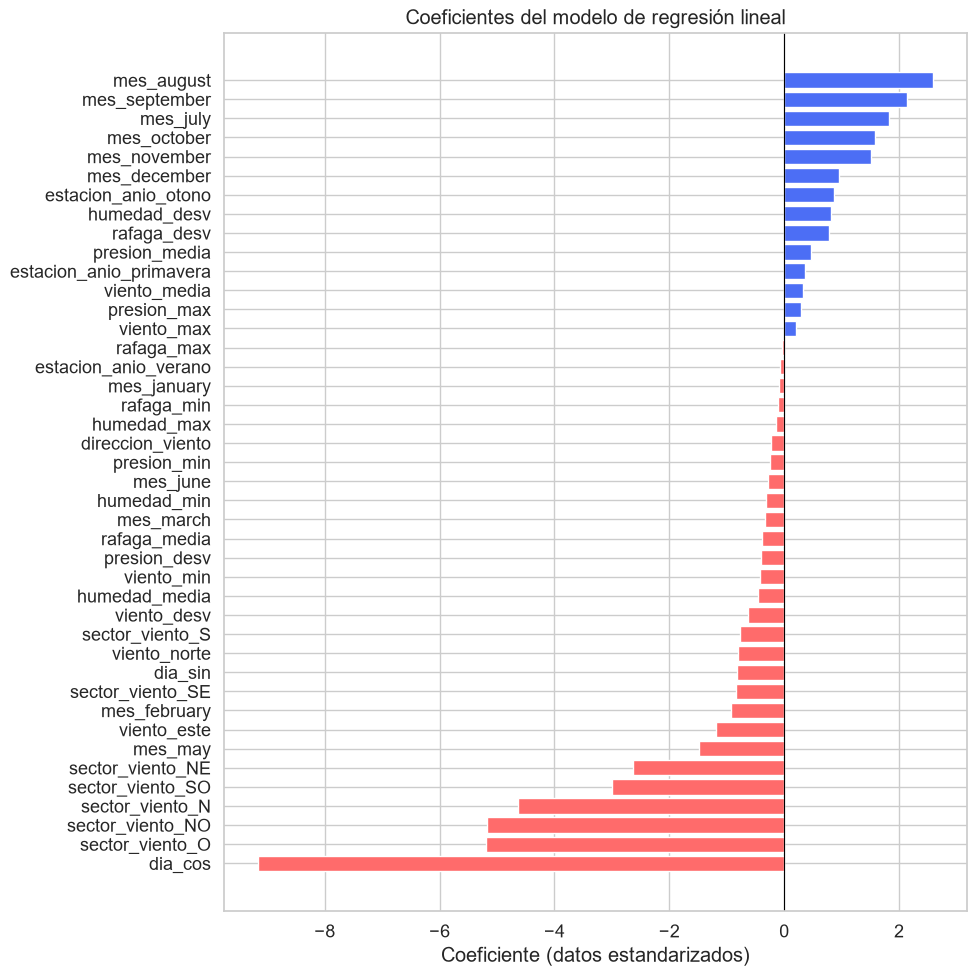

In [53]:
coef_ordenado = coef_df.sort_values("Coeficiente")
colores = ["#FF6B6B" if c < 0 else "#4C6EF5" for c in coef_ordenado["Coeficiente"]]

plt.figure(figsize=(10,10))
plt.barh(coef_ordenado["Variable"], coef_ordenado["Coeficiente"], color = colores)
plt.axvline(0, color="black", linewidth = 0.8)
plt.xlabel("Coeficiente (datos estandarizados)")
plt.title("Coeficientes del modelo de regresión lineal")
plt.tight_layout()
plt.show()


La variable con mayor impacto es **dia_cos** (coeficiente de -8.94) que captura la estacionalidad anual. Los valores negativos del coseno corresponden a los meses de verano donde la temperatura maxima es mayor. Le siguen los sectores del viento del oeste y noroeste con coeficientes negativos (5.20 y -5.18), lo que dice que los vientos provenientees del atlántico se asocian con temperaturas más bajas. Dado que las variables numéricas están estandarizadas, los coeficientes son comparables entre sí en magnitud. Sin embargo, su interpretación individual depende de que se cumplan los supuestos del modelo a continuación.

#### 6.4 Multicolinealidad (vif)

In [54]:
vif_values = []
with np.errstate(divide = "ignore", invalid="ignore"):
    for i in range(Xt_train_df.shape[1]):
        vif_values.append(variance_inflation_factor(Xt_train_df.values, i))

vif_data = pd.DataFrame({"Variable": nombres_variables, "VIF": vif_values})
vif_data.sort_values("VIF", ascending = False).head(15)


,Variable,VIF
20,dia_cos,38.253537
11,viento_desv,26.349668
16,viento_norte,23.060859
19,dia_sin,22.531212
0,presion_media,17.592895
41,sector_viento_SO,14.611528
33,mes_october,13.641225
34,mes_september,13.518499
32,mes_november,12.069671
24,mes_august,11.819021


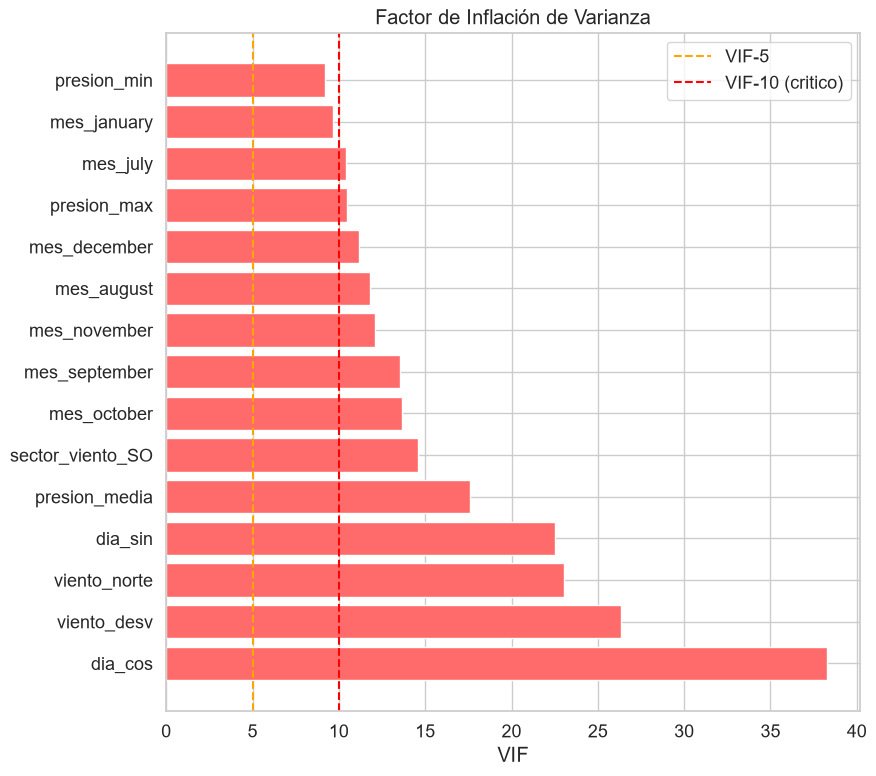

In [56]:
vif_ordenado = vif_data.sort_values("VIF", ascending = False).head(15)
colores_vif = ["#FF6B6B" if v >= 5 else "#4C6EF5" for v in vif_ordenado["VIF"]]

plt.figure(figsize = (9, 8))
plt.barh(vif_ordenado["Variable"], vif_ordenado["VIF"], color = colores_vif)
plt.axvline(5, color="orange", linestyle = "--", lw=1.5, label = "VIF-5")
plt.axvline(10, color="red", linestyle = "--", lw=1.5, label = "VIF-10 (critico)")
plt.xlabel("VIF")
plt.title("Factor de Inflación de Varianza")
plt.legend()
plt.tight_layout()
plt.show()


Los VIF más altos corresponden a **dia_sin** (43.8) y **dia_cos** (38.4), seguidos por los meses del año (VIF entre 23 y 33). Esto se explica por la redundancia estacional (invierno a inicio de año y fin de año). Los coeficientes individuales de estas svariables son inestables y no deben interpretarse de forma aislada, aunque el modelo en conjunto predice correctamente. Tampoco se detectaron VIF infinitos.

#### 6.5 Verificación de supuestos

In [58]:
#Normalidad
_, p_shapiro = shapiro(residuales)
print("Shapiro-Wilk p-value:", round(p_shapiro, 4))

#Homocedasticidad
Xt_const = sm.add_constant(Xt_train_df)
_, p_bp, _, _ = het_breuschpagan(residuales, Xt_const)
print("Breush-pagan p-value:", round(p_bp, 4))

#Independencia
dw = durbin_watson(residuales)
print("Durbin-watson:", round(dw, 4))

#Linealidad
modelo_sm = sm.OLS(y_train, Xt_const).fit()
_, p_rainbow = linear_rainbow(modelo_sm)
print("Rainbow p-value:", round(p_rainbow, 4))

Shapiro-Wilk p-value: 0.2874
Breush-pagan p-value: 0.0045
Durbin-watson: 2.0191
Rainbow p-value: 0.068


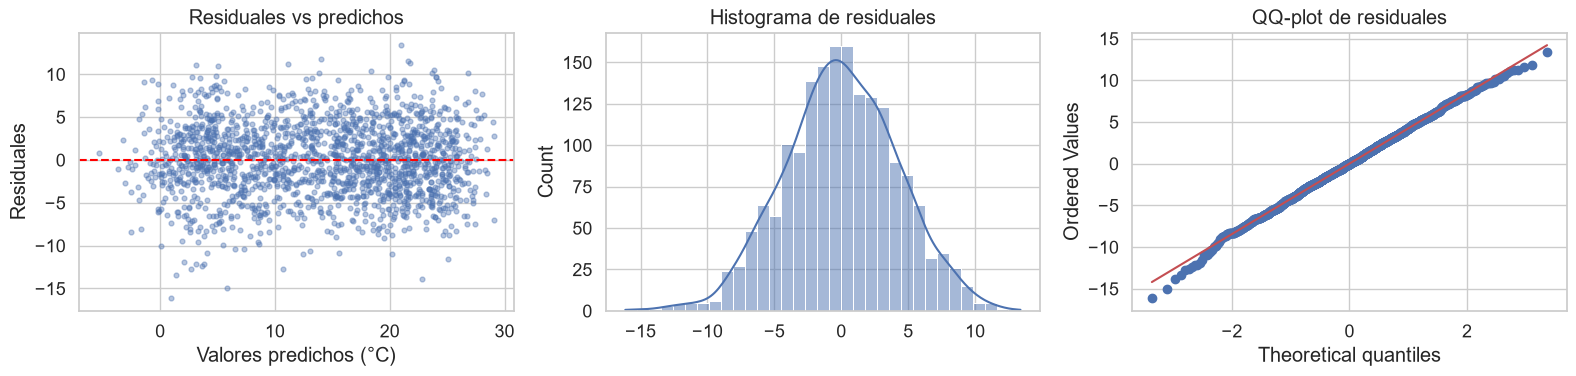

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(y_train_pred, residuales, alpha=0.4, s=12)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Valores predichos (°C)")
axes[0].set_ylabel("Residuales")
axes[0].set_title("Residuales vs predichos")

sns.histplot(residuales, kde=True, ax=axes[1])
axes[1].set_title("Histograma de residuales")

stats.probplot(residuales, dist="norm", plot=axes[2])
axes[2].set_title("QQ-plot de residuales")

plt.tight_layout()
plt.show()

Como se puede observar, los residuales tienen la forma aproximada de una distribución Gausseana, por lo que la normalidad de los residuales se cumple (p = 0.175), lo cual es coherente con la naturaleza de la variable: la temperatura es una medición física continua, sin la asimetría que presentan las variables como precios. La independencia también se cumple (Durbin-Watson = 2.o2), lo que indica que los errores no están autocorrelacionados entre observaciones consecutivas. La linealidad no se rechaza, aunque con un p-value cercano al umbral (0.061). El único supuesto que falla es la homocedasticidad (p = 0.0024) debido a que el modelo se equivoca con mayor intensidad en ciertos rangos de temperatura que en otros, lo que implica que los errores estándar de los coeficientes podrían estar mal estimados. 

### 7 Exportar CSV

In [ ]:
# (1) Aplicar la misma limpieza que se hizo en la Sección 3
limpio = sin_etiqueta.copy()

# 3.1 Fecha y calendario
fecha_parseada = pd.to_datetime(limpio["fecha"], format="%d.%m.%Y", errors="coerce")
limpio["fecha"] = fecha_parseada
limpio["anio"] = fecha_parseada.dt.year
limpio["dia_del_anio"] = fecha_parseada.dt.dayofyear
limpio["mes"] = fecha_parseada.dt.strftime("%B").str.lower()
limpio["registros_del_dia"] = limpio["registros_del_dia"].astype("Int64")
limpio["anio"] = limpio["anio"].astype("Int64")
limpio["dia_del_anio"] = limpio["dia_del_anio"].astype("Int64")

# 3.2 Categorías
limpio["estacion_anio"] = limpio["estacion_anio"].str.strip().str.lower().map(MAPA_ESTACION)
limpio["sector_viento"] = limpio["sector_viento"].str.strip().str.lower().map(MAPA_SECTOR)

# 3.3 Validez
limpio = limpio.replace([-9999, -999, 9999], np.nan)
limpio.loc[(limpio["presion_media"] < 850) | (limpio["presion_media"] > 1100), "presion_media"] = np.nan
for col in ["humedad_media", "humedad_min"]:
    mask = limpio[col] <= 1
    limpio.loc[mask, col] = limpio.loc[mask, col] * 100
limpio.loc[limpio["humedad_min"] > 100, "humedad_min"] = np.nan
limpio.loc[limpio["rafaga_desv"] < 0, "rafaga_desv"] = np.nan
limpio.loc[limpio["rafaga_media"] < 0, "rafaga_media"] = np.nan
limpio.loc[limpio["rafaga_desv"] > 20, "rafaga_desv"] = np.nan
mask = limpio["viento_desv"] > 20
limpio.loc[mask, "viento_desv"] = limpio.loc[mask, "viento_desv"] / 100
limpio.loc[limpio["viento_min"] > limpio["viento_max"], "viento_min"] = np.nan
limpio.loc[limpio["rafaga_min"] > limpio["rafaga_max"], "rafaga_min"] = np.nan

# (2) Preparar X con las mismas columnas
X_entrega = limpio.drop(columns=COLUMNAS_ELIMINADAS, errors="ignore")
X_entrega = X_entrega.reindex(columns=X.columns)

print("Filas a predecir:", len(X_entrega))
print("Filas del archivo original:", len(sin_etiqueta))